In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:36070")
client

<Client: 'tcp://127.0.0.1:36070' processes=8 threads=32, memory=503.70 GiB>

In [11]:
import numpy as np
import xarray as xr
import pandas as pd
from xhistogram.xarray import histogram as xhist

import gsw

import os.path as op

import warnings
warnings.filterwarnings("ignore")

from matplotlib import ticker
import matplotlib.colors as clr
import matplotlib.pyplot as plt
plt.rcParams['pcolor.shading'] = 'auto'
%matplotlib inline

In [3]:
grav = 9.807
meth = "linear"
ddir = "/storage/tartar/takaya/swot/"

In [7]:
ipass = 1
dssh = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass%03d/SSHa.zarr" 
                            % ipass)
                   )
dssh

<xarray.Dataset> Size: 486MB
Dimensions:     (cycle_num: 105, num_lines: 9310, num_pixels: 61)
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 74kB 1 2 3 4 5 6 ... 9854 9855 9856 9857 9858
  * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
    latitude    (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
    longitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
Data variables:
    ssha        (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>

In [8]:
dssv = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass%03d/SSVs_SwotDiag.zarr"
                            % ipass)
                   )
dssv

<xarray.Dataset> Size: 3GB
Dimensions:     (cycle_num: 105, num_lines: 9310, num_pixels: 61)
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 74kB 1 2 3 4 5 6 ... 9854 9855 9856 9857 9858
  * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
    latitude    (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
    longitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
Data variables:
    strain      (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
    ucg         (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
    ug          (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
    vcg         (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
    vg          (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
    vort        (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>

In [9]:
maskn1 = xr.DataArray(dssh.latitude.where(dssh.latitude>-38.2).to_masked_array().mask,
                     dims=dssh.latitude.dims,
                     coords=dssh.latitude.coords
                    )
masks1 = xr.DataArray(dssh.latitude.where(dssh.latitude<-33).to_masked_array().mask,
                     dims=dssh.latitude.dims,
                     coords=dssh.latitude.coords
                    )

In [15]:
agu_re_h = dssh.ssha.where(~maskn1,drop=True).where(~masks1,drop=True)
agu_re_v = dssv.vort.where(~maskn1,drop=True).where(~masks1,drop=True)
agu_re_s = dssv.strain.where(~maskn1,drop=True).where(~masks1,drop=True)
agu_re_h, agu_re_v

(<xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 308, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 308, 61), dtype=float64, chunksize=(1, 308, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 2kB 2778 2779 2780 2781 ... 3083 3084 3085
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 150kB -38.19 -38.19 ... -33.01
     longitude   (num_lines, num_pixels) float64 150kB 14.64 14.66 ... 17.35,
 <xarray.DataArray 'vort' (cycle_num: 105, num_lines: 308, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 308, 61), dtype=float64, chunksize=(1, 308, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 2kB 2778 2779 2780 2781 ... 3083 3084 3085
   * num_pixels  (num_pixels) int

Text(0.5, 1.0, '$|\\alpha^g|/|f|$')

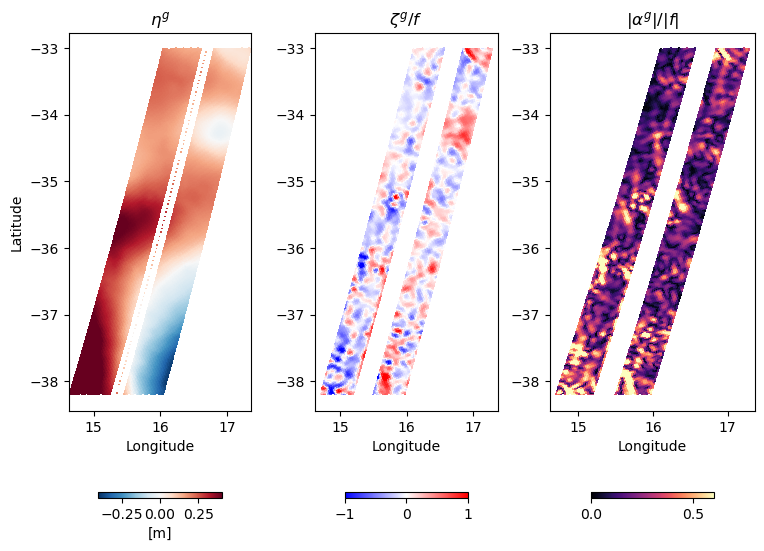

In [18]:
cnum = 20
cori = gsw.f(agu_re_h.isel(cycle_num=cnum).latitude)
fig, (ax1,ax2,ax3) = plt.subplots(figsize=(9,7), nrows=1, ncols=3)
# fig.set_tight_layout(True)
im1 = ax1.pcolormesh(agu_re_h.isel(cycle_num=cnum).longitude, 
                   agu_re_h.isel(cycle_num=cnum).latitude,
                   agu_re_h.isel(cycle_num=cnum),
                   vmin=-.4, vmax=.4, cmap="RdBu_r",
                   rasterized=True)
im2 = ax2.pcolormesh(agu_re_v.isel(cycle_num=cnum).longitude, 
                   agu_re_v.isel(cycle_num=cnum).latitude,
                   agu_re_v.isel(cycle_num=cnum)/cori,
                   vmin=-1., vmax=1., cmap="bwr",
                   rasterized=True)
im3 = ax3.pcolormesh(agu_re_s.isel(cycle_num=cnum).longitude, 
                   agu_re_s.isel(cycle_num=cnum).latitude,
                   agu_re_s.isel(cycle_num=cnum)/np.abs(cori),
                   vmin=0., vmax=.6, cmap="magma",
                   rasterized=True)
ax1.set_aspect("equal")
ax2.set_aspect("equal")
ax1.set_xlabel(r"Longitude")
ax1.set_ylabel(r"Latitude")
ax2.set_xlabel(r"Longitude")
ax3.set_xlabel(r"Longitude")
cbar1 = fig.colorbar(im1, ax=ax1, orientation="horizontal", shrink=.6)
cbar1.set_label(r"[m]")
cbar2 = fig.colorbar(im2, ax=ax2, orientation="horizontal", shrink=.6)
cbar3 = fig.colorbar(im3, ax=ax3, orientation="horizontal", shrink=.6)
ax1.set_title(r"$\eta^g$")
ax2.set_title(r"$\zeta^g/f$")
ax3.set_title(r"$|\alpha^g|/|f|$")